In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("resultados.csv")

# Promediar las 10 iteraciones por configuración
promedios = df.groupby(["tipo", "puntos", "dims", "hilos"])["tiempo_ms"].mean().reset_index()

# Separar serial y paralelo
serial   = promedios[promedios["tipo"] == "serial"][["puntos", "dims", "tiempo_ms"]].rename(columns={"tiempo_ms": "tiempo_serial"})
paralelo = promedios[promedios["tipo"] == "paralelo"]

# Unir por puntos y dims para calcular speedup
merged = paralelo.merge(serial, on=["puntos", "dims"])
merged["speedup"] = merged["tiempo_serial"] / merged["tiempo_ms"]

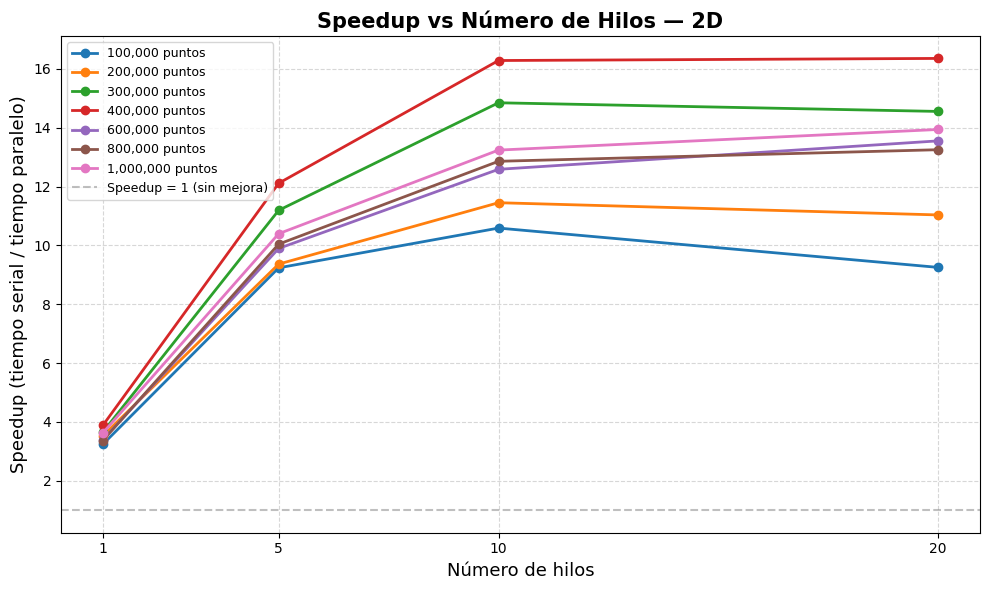

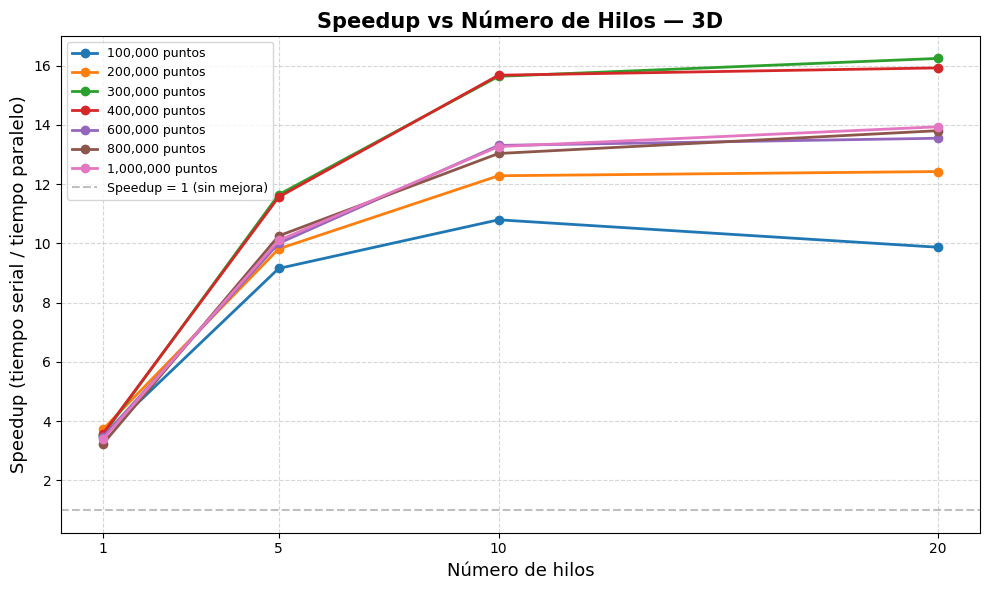

In [10]:
# Una gráfica por dimensión
for dims in [2, 3]:
    subset = merged[merged["dims"] == dims]

    plt.figure(figsize=(10, 6))

    for n in sorted(subset["puntos"].unique()):
        data = subset[subset["puntos"] == n].sort_values("hilos")
        plt.plot(data["hilos"], data["speedup"], marker="o", linewidth=2, label=f"{n:,} puntos")

    # Línea de speedup ideal (lineal)
    plt.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Speedup = 1 (sin mejora)")

    plt.title(f"Speedup vs Número de Hilos — {dims}D", fontsize=15, fontweight="bold")
    plt.xlabel("Número de hilos", fontsize=13)
    plt.ylabel("Speedup (tiempo serial / tiempo paralelo)", fontsize=13)
    plt.xticks([1, 5, 10, 20])
    plt.legend(fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"speedup_{dims}d.png", dpi=150)
    plt.show()
    plt.close()


In [12]:
print("\nTABLA DE SPEEDUPS")
print("="*65)
print(merged[["puntos", "dims", "hilos", "tiempo_serial", "tiempo_ms", "speedup"]].round(2).to_string(index=False))
print("="*65)


TABLA DE SPEEDUPS
 puntos  dims  hilos  tiempo_serial  tiempo_ms  speedup
 100000     2      1          29.36       9.07     3.24
 100000     2      5          29.36       3.18     9.24
 100000     2     10          29.36       2.77    10.59
 100000     2     20          29.36       3.17     9.25
 100000     3      1          71.19      20.40     3.49
 100000     3      5          71.19       7.78     9.15
 100000     3     10          71.19       6.59    10.80
 100000     3     20          71.19       7.21     9.87
 200000     2      1         177.35      50.33     3.52
 200000     2      5         177.35      18.94     9.36
 200000     2     10         177.35      15.49    11.45
 200000     2     20         177.35      16.07    11.03
 200000     3      1        1330.41     357.46     3.72
 200000     3      5        1330.41     135.54     9.82
 200000     3     10        1330.41     108.32    12.28
 200000     3     20        1330.41     107.08    12.42
 300000     2      1         